In [28]:
import os
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams

#%matplotlib inline

# plot style
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# to prevent ROOT errors
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

#set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"


sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

# -------------------------------
# load processed data (PKL)
# -------------------------------

processed_folder = "/scratch/elena/9Li/results/run1846/processed"
processed_files = sorted(glob(f"{processed_folder}/*.pkl"))

match = re.search(r'run(\d+)', processed_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"

print(f"Found {len(processed_files)} processed files.")

if len(processed_files) > 0:
    geo_data = functions_bonsai.get_geo_mapping()
    lookup = functions_bonsai.build_lookup_table(geo_data)


    dfs = [pd.read_pickle(f) for f in processed_files]
    df_all = pd.concat(dfs, ignore_index=True)

    print(f"Total clusters loaded: {len(df_all)}")

    # chi2/ndof
    if 'chi2_ndof' in df_all.columns:
        valid_fits = df_all[df_all['fit_success'] == True]
        print(f"Fit success: {len(valid_fits)}")

Run number: 1846
Found 50 processed files.
Total clusters loaded: 201875
Fit success: 200366


In [29]:
df_all.head()

,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,nCLusters_in_spill,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,vertex_x,vertex_y,vertex_z,fit_success,n_hits_used,time_rms,chi2,ndof,chi2_ndof
0,8.020664e+09,235172.835303,18,0,670,"[16, 96, 132, 132, 132, 132, 132, 132, 130, 13...","[73, 8, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1...","[8, 7, 1, 2, 4, 11, 13, 10, 3, 8, 0, 1, 2, 6, ...","[9, 2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2,...","[8020664062.996114, 8020664072.270257, 8020664...","[114.0, 87.0, 224.0, 2090.0, 4105.0, 911.0, 15...",NaN,NaN,NaN,False,2,NaN,NaN,NaN,NaN
1,8.020986e+09,557196.809196,22,0,670,"[10, 34, 26, 15, 21, 42, 98, 98, 89, 99, 19, 1...","[61, 78, 60, 58, 64, 80, 100, 100, 89, 90, 41,...","[4, 1, 14, 15, 5, 3, 3, 7, 2, 7, 14, 2, 5, 10,...","[1, 6, 13, 5, 7, 18, 18, 2, 0, 2, 13, 0, 7, 10...","[8020986088.004007, 8020986090.157587, 8020986...","[242.0, 228.0, 379.0, 169.0, 109.0, 68.0, 160....",36.711720,13.904229,-169.724039,True,22,1.107696,27.175056,18.0,1.509725
2,8.020998e+09,569447.330278,49,0,670,"[10, 10, 25, 25, 35, 26, 23, 83, 80, 80, 73, 4...","[61, 61, 62, 62, 76, 60, 47, 28, 30, 30, 31, 4...","[15, 16, 2, 8, 12, 1, 15, 19, 4, 6, 4, 15, 16,...","[5, 14, 0, 9, 4, 6, 5, 4, 1, 8, 1, 5, 14, 9, 1...","[8020998354.90268, 8020998356.207907, 80209983...","[223.0, 302.0, 206.0, 67.0, 104.0, 120.0, 113....",11.748921,-33.033640,-81.431154,True,44,0.823723,29.856659,40.0,0.746416
3,8.021034e+09,605344.839068,57,0,670,"[73, 44, 71, 78, 78, 78, 78, 78, 78, 78, 78, 7...","[31, 43, 103, 33, 33, 33, 33, 33, 33, 33, 33, ...","[11, 15, 9, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 1...","[11, 5, 3, 6, 0, 18, 1, 2, 9, 3, 10, 11, 4, 12...","[8021034242.182418, 8021034249.055196, 8021034...","[211.0, 127.0, 130.0, 497.0, 1043.0, 201.0, 68...",-175.658343,-141.499085,27.475499,True,57,1.542880,135.978819,53.0,2.565638
4,8.021263e+09,834125.819131,16,0,670,"[99, 97, 22, 24, 84, 102, 82, 117, 117, 132, 1...","[90, 92, 82, 71, 87, 22, 7, 5, 5, -1, -1, -1, ...","[12, 17, 15, 10, 5, 3, 17, 9, 18, 17, 18, 13, ...","[4, 15, 5, 10, 7, 18, 15, 3, 16, -2, -2, -2, -...","[8021263020.478534, 8021263021.806006, 8021263...","[121.0, 168.0, 111.0, 105.0, 123.0, 146.0, 139...",-46.127092,-6.450361,142.346122,True,9,3.108851,87.922245,5.0,17.584449


In [30]:
df_all.columns

Index(['t_window_start_ns', 't_window_start_rel_ns', 'nHits', 'spill_id',
       'nCLusters_in_spill', 'hit_card_ids', 'hit_slot_ids', 'hit_channel_ids',
       'hit_position_ids', 'hit_times_ns', 'hit_charges', 'vertex_x',
       'vertex_y', 'vertex_z', 'fit_success', 'n_hits_used', 'time_rms',
       'chi2', 'ndof', 'chi2_ndof'],
      dtype='object')

In [31]:
def clean_hits(ids, times, charges):
    
    ids = np.array(ids)
    times = np.array(times)

    charges = np.array(charges) if isinstance(charges, (list, np.ndarray)) else np.zeros_like(ids)

    mask = ids >= 0

    return (
        ids[mask],
        times[mask],
        charges[mask] if len(charges) == len(ids) else charges
    )

all_data_mpmts = set()

for row in df_all.iloc[:100].itertuples():
    ids, times, charges = clean_hits(
        row.hit_slot_ids,
        row.hit_times_ns,
        row.hit_charges
    )
    
    all_data_mpmts.update(ids)

print([int(x) for x in sorted(list(all_data_mpmts))])

print("min ID:", min(all_data_mpmts))
print("max ID:", max(all_data_mpmts))
print("total unique:", len(all_data_mpmts))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 13, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 64, 65, 66, 68, 69, 70, 71, 72, 73, 75, 76, 78, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 92, 93, 94, 95, 97, 98, 100, 101, 103, 104, 105]
min ID: 0
max ID: 105
total unique: 83


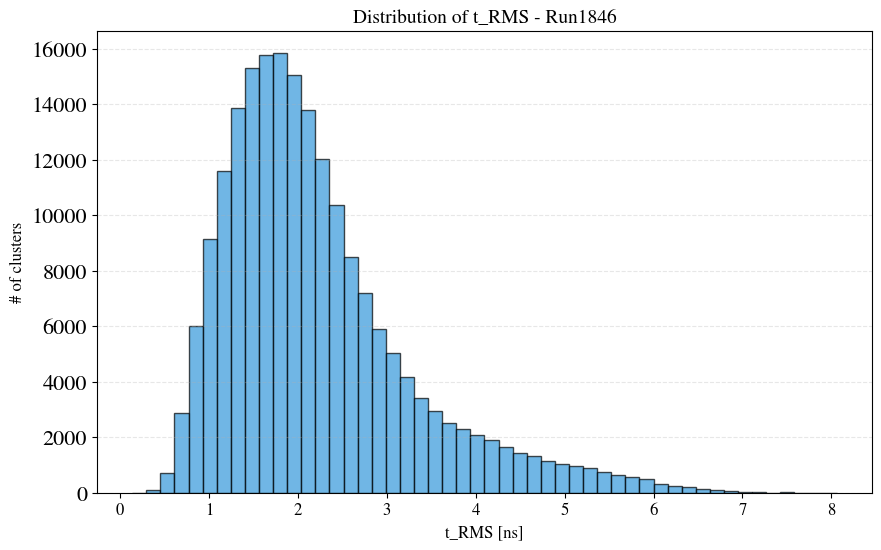

In [32]:
rms_values = df_all[df_all['fit_success'] == True]['time_rms']
current_cut = 3.0 

#historgram T_RMS

plt.figure(figsize=(10, 6))

counts, bins, _ = plt.hist(rms_values, bins=50, color='#3498db', edgecolor='black', alpha=0.7, label='Reconstructed Events')

#plt.axvline(current_cut, color='red', linestyle='--', linewidth=2, label=f'cut: {current_cut} ns')


plt.title(f"Distribution of t_RMS - Run{run_number}", fontsize=14)
plt.xlabel("t_RMS [ns]", fontsize=12)
plt.ylabel("# of clusters", fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
#plt.legend()


plt.show()

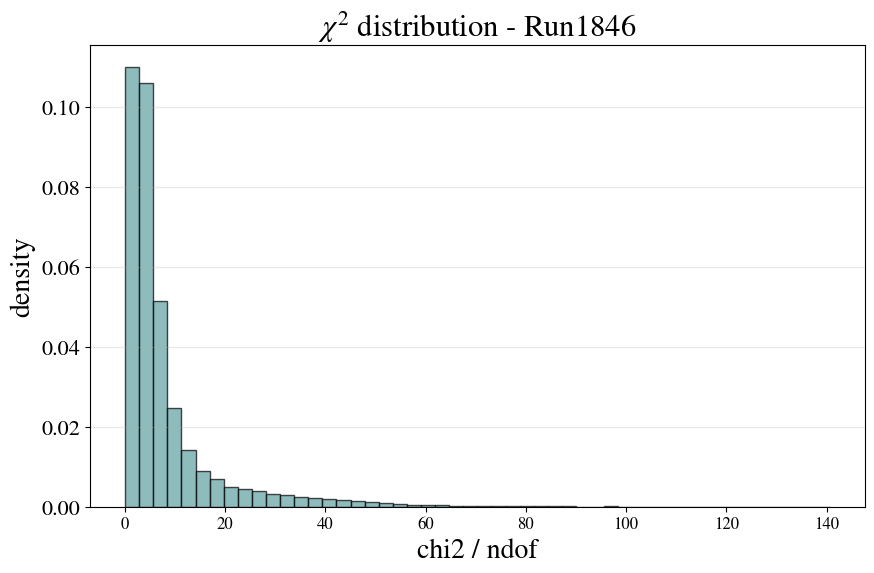

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(df_all['chi2_ndof'].dropna(), bins=50, color='cadetblue', alpha=0.7, edgecolor='black', density=True)

#plt.axvline(1.0, color='red', linestyle='--', label="Ideal (chi2/ndof=1)")
plt.title(f"$\chi^2$ distribution - Run{run_number}", fontsize=22)
plt.xlabel("chi2 / ndof")
plt.ylabel("density")
#plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

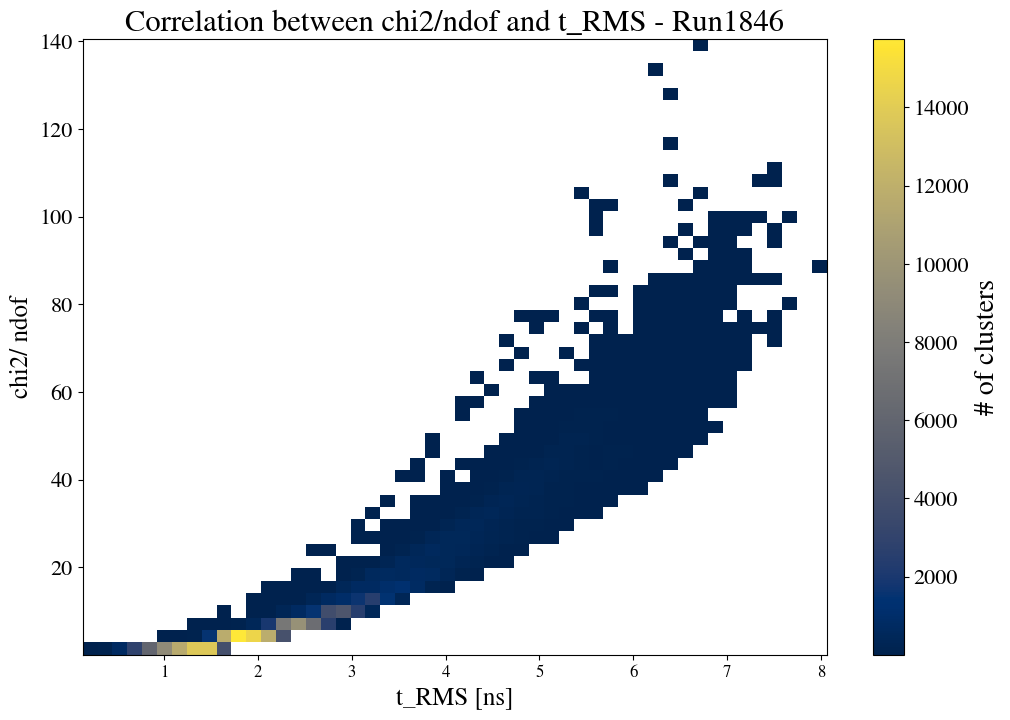

In [34]:
valid_data = df_all[df_all['fit_success'] == True].dropna(subset=['chi2_ndof', 'time_rms'])

plt.figure(figsize=(12, 8))

h = plt.hist2d(valid_data['time_rms'], 
               valid_data['chi2_ndof'], 
               bins=50, 
               cmap='cividis',
               cmin=1)


#plt.axvline(3.0, color='red', linestyle='--', label='t_RMS cut')
#plt.axhline(50, color='orange', linestyle=':', label='Chi2 cut')


cb = plt.colorbar(h[3], label='# of clusters')

plt.title(f'Correlation between chi2/ndof and t_RMS - Run{run_number}', fontsize=22)
plt.xlabel('t_RMS [ns]', fontsize=18)
plt.ylabel(r'chi2/ ndof', fontsize=18)
#plt.legend()
plt.show()

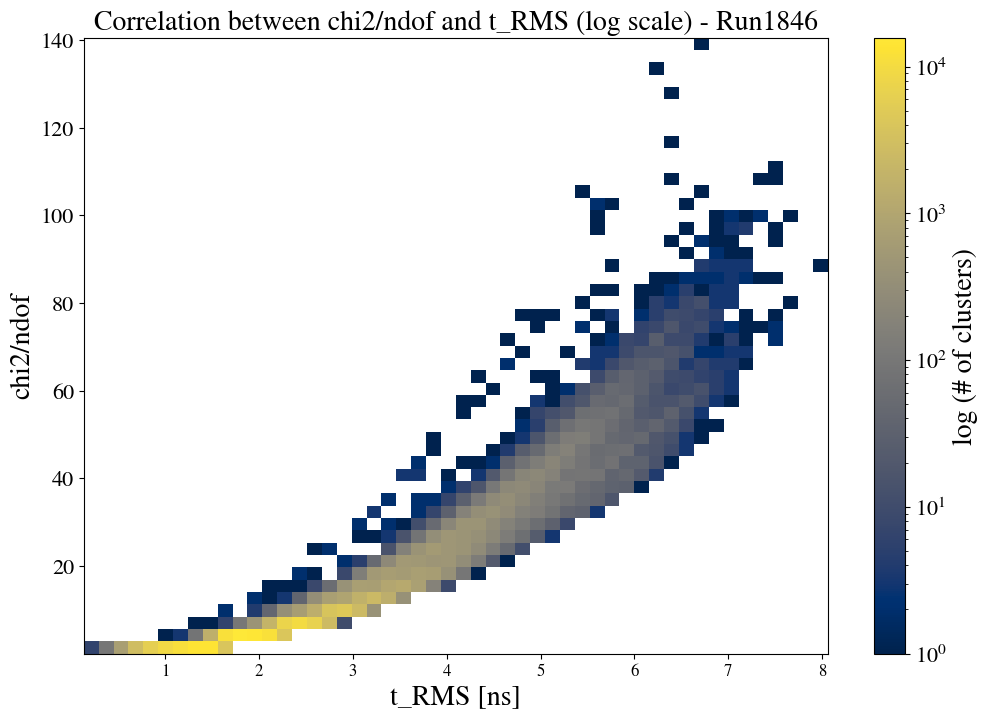

In [35]:
import matplotlib.colors as mcolors

plt.figure(figsize=(12, 8))

h = plt.hist2d(valid_data['time_rms'], 
               valid_data['chi2_ndof'], 
               bins=50, 
               cmap='cividis',
               cmin=1,
               norm=mcolors.LogNorm()) 

cb = plt.colorbar(h[3], label='log (# of clusters)')

plt.title(f'Correlation between chi2/ndof and t_RMS (log scale) - Run{run_number}')
plt.xlabel('t_RMS [ns]')
plt.ylabel(r'chi2/ndof')

plt.show()

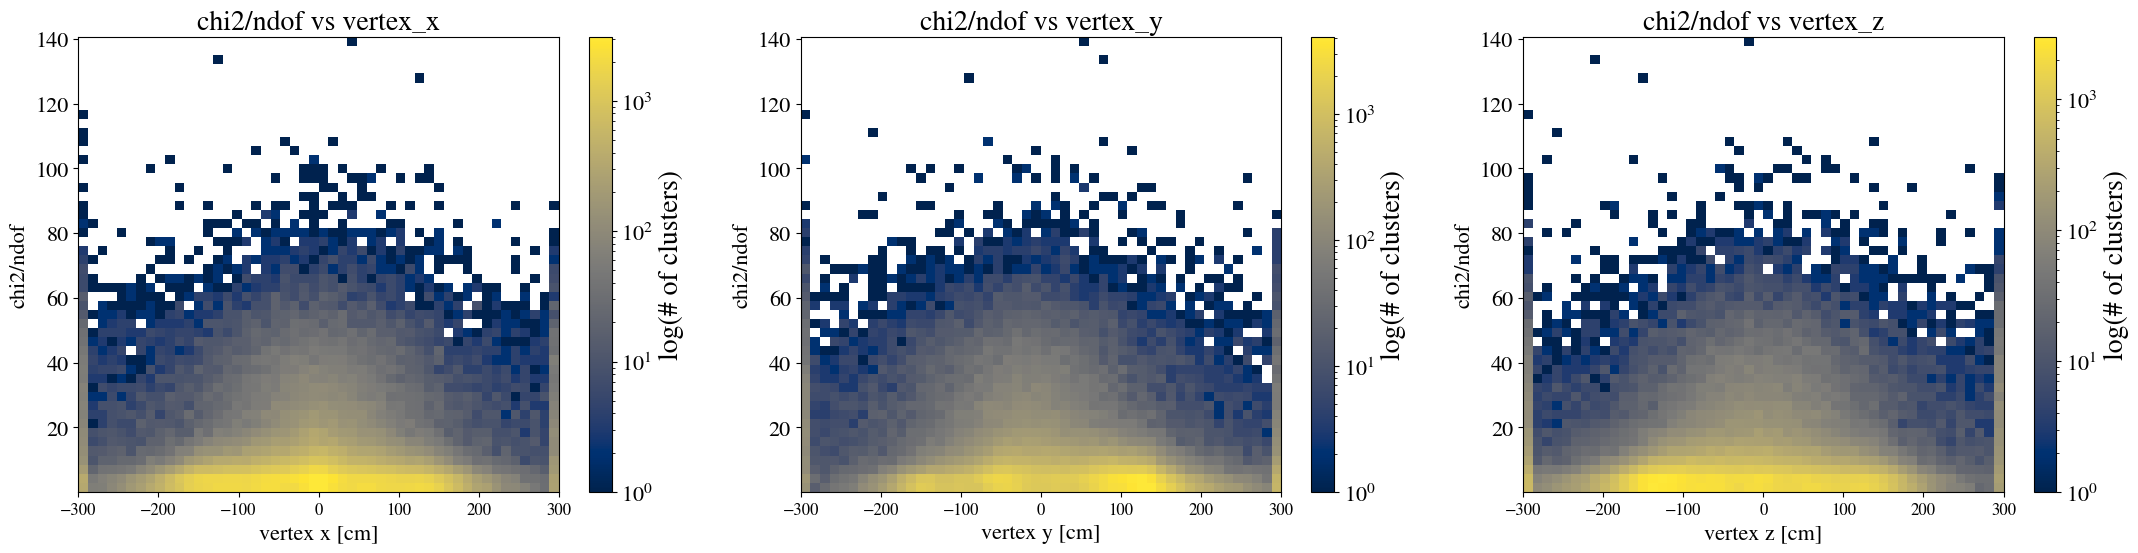

In [36]:
valid_data = df_all[df_all['fit_success'] == True].dropna(subset=['chi2_ndof', 'vertex_x', 'vertex_y', 'vertex_z'])

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

coords = ['vertex_x', 'vertex_y', 'vertex_z']
labels = ['vertex x [cm]', 'vertex y [cm]', 'vertex z [cm]']

for i, coord in enumerate(coords):

    h = axes[i].hist2d(valid_data[coord], 
                       valid_data['chi2_ndof'], 
                       bins=50, 
                       cmap='cividis', 
                       cmin=1, 
                       norm=mcolors.LogNorm())
    
    axes[i].set_title(f'chi2/ndof vs {coord}', fontsize=20)
    axes[i].set_xlabel(labels[i], fontsize=16)
    axes[i].set_ylabel('chi2/ndof', fontsize=16)

    fig.colorbar(h[3], ax=axes[i], label='log(# of clusters)')

plt.tight_layout()
plt.show()

# of events: 200366
# events if chi2/ndof < 5: 110755


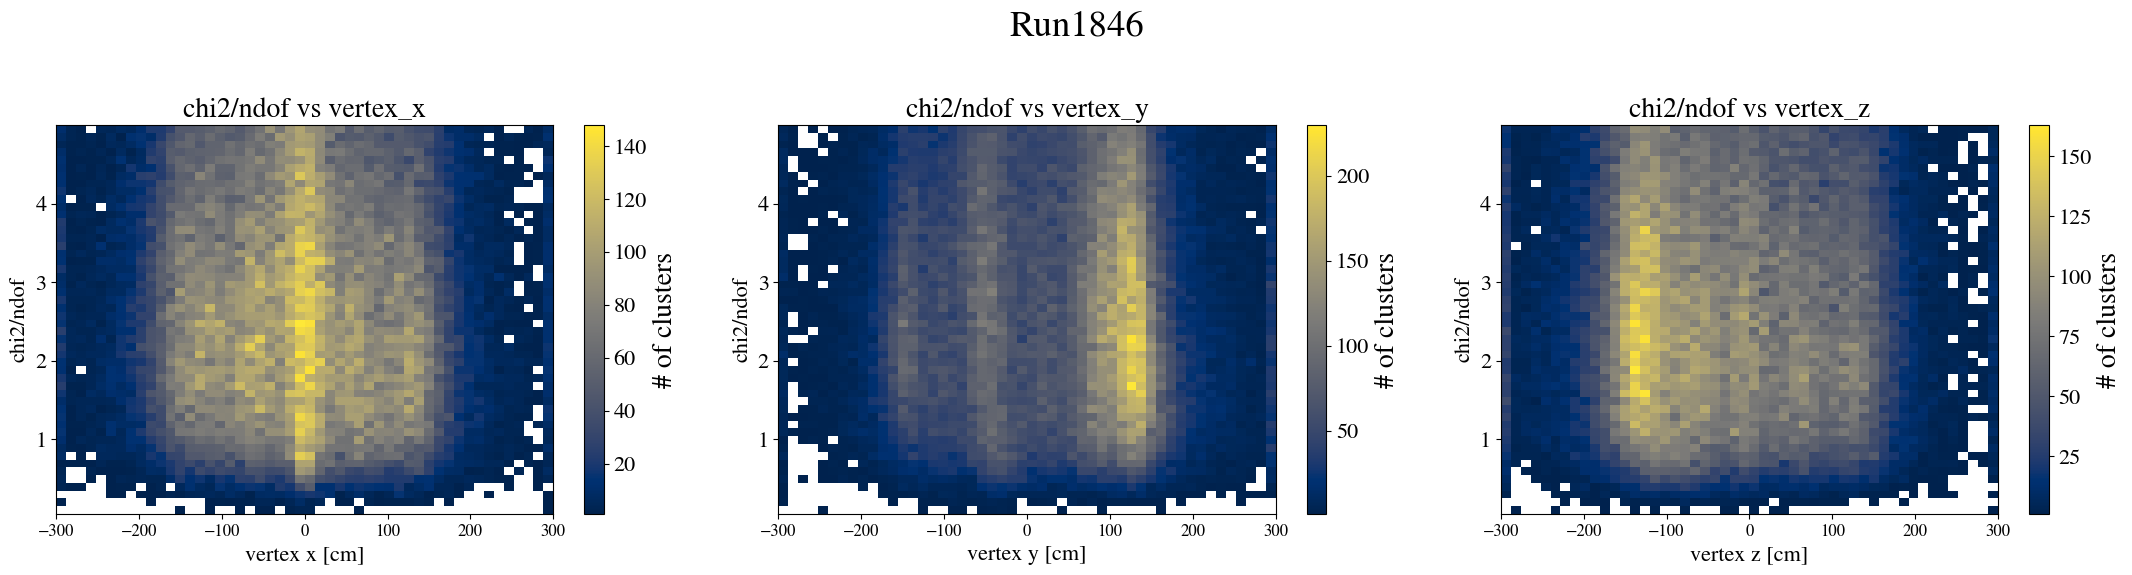

In [37]:
filtered_data = valid_data[valid_data['chi2_ndof'] < 5].copy()
beam_coords = [0.0, -42.47, -138.79] 

print(f"# of events: {len(valid_data)}")
print(f"# events if chi2/ndof < 5: {len(filtered_data)}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

coords = ['vertex_x', 'vertex_y', 'vertex_z']
labels = ['vertex x [cm]', 'vertex y [cm]', 'vertex z [cm]']

for i, coord in enumerate(coords):
    h = axes[i].hist2d(filtered_data[coord], 
                       filtered_data['chi2_ndof'], 
                       bins=50, 
                       cmap='cividis', 
                       cmin=1)
    
    axes[i].set_title(f'chi2/ndof vs {coord}', fontsize=20)
    axes[i].set_xlabel(labels[i], fontsize=16)
    axes[i].set_ylabel('chi2/ndof', fontsize=16)
    #axes[i].axvline(beam_coords[i], color='red', linestyle='-.', linewidth=2, label=f'Beam ({beam_coords[i]} cm)')
    
    fig.colorbar(h[3], ax=axes[i], label='# of clusters')

plt.suptitle(f"Run{run_number}")
plt.tight_layout()
plt.show()

# of events: 200366
# events if chi2/ndof < 5: 110755


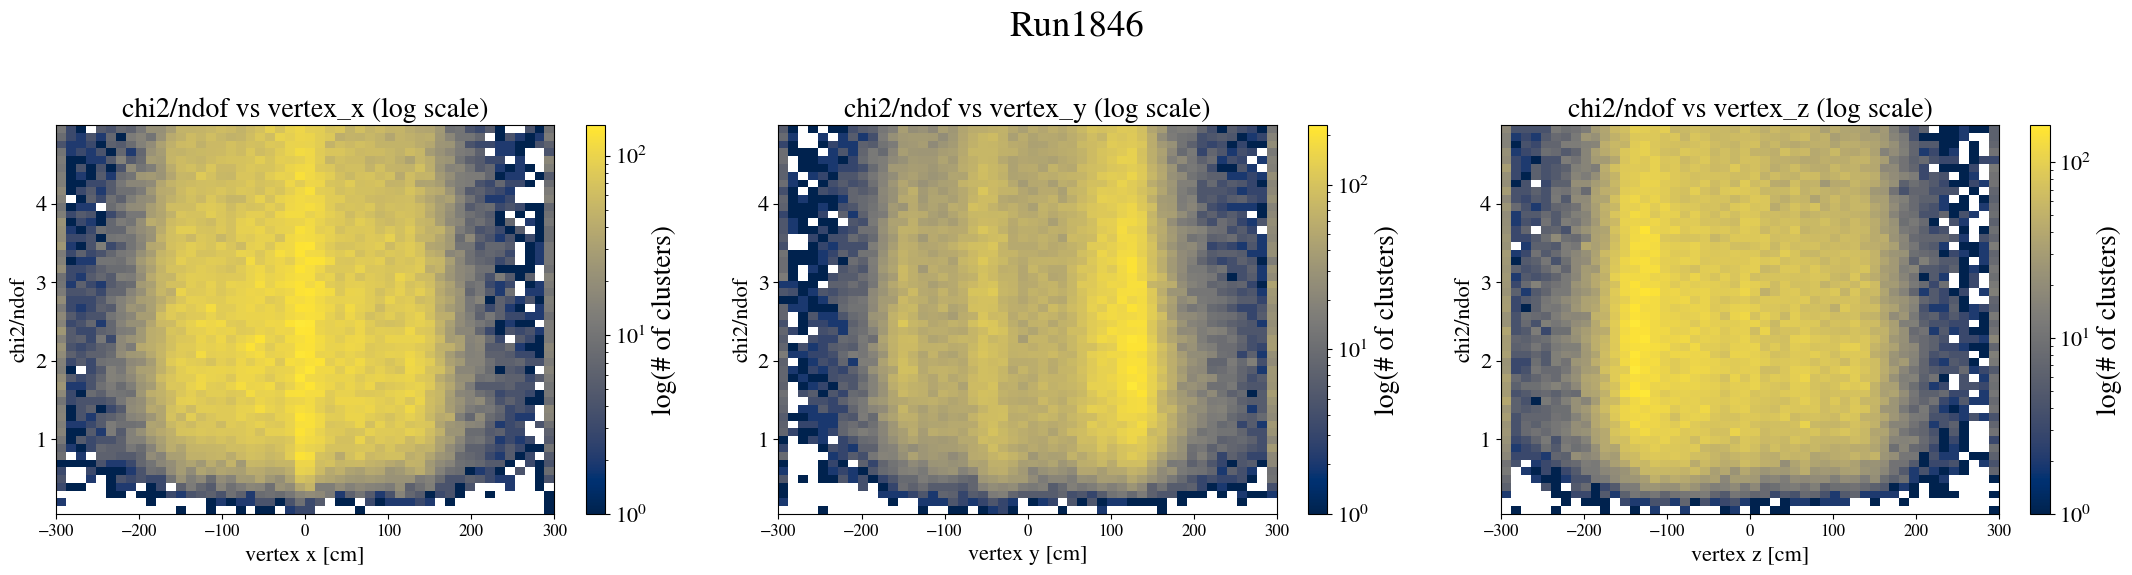

In [38]:
filtered_data = valid_data[valid_data['chi2_ndof'] < 5].copy()
beam_coords = [0.0, -42.47, -138.79] 

print(f"# of events: {len(valid_data)}")
print(f"# events if chi2/ndof < 5: {len(filtered_data)}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

coords = ['vertex_x', 'vertex_y', 'vertex_z']
labels = ['vertex x [cm]', 'vertex y [cm]', 'vertex z [cm]']

for i, coord in enumerate(coords):
    h = axes[i].hist2d(filtered_data[coord], 
                       filtered_data['chi2_ndof'], 
                       bins=50, 
                       cmap='cividis', 
                       cmin=1, 
                       norm=mcolors.LogNorm())
    
    axes[i].set_title(f'chi2/ndof vs {coord} (log scale)', fontsize=20)
    axes[i].set_xlabel(labels[i], fontsize=16)
    axes[i].set_ylabel('chi2/ndof', fontsize=16)
    #axes[i].axvline(beam_coords[i], color='red', linestyle='-.', linewidth=2, label=f'Beam ({beam_coords[i]} cm)')
    
    fig.colorbar(h[3], ax=axes[i], label='log(# of clusters)')

plt.suptitle(f"Run{run_number}")
plt.tight_layout()
plt.show()

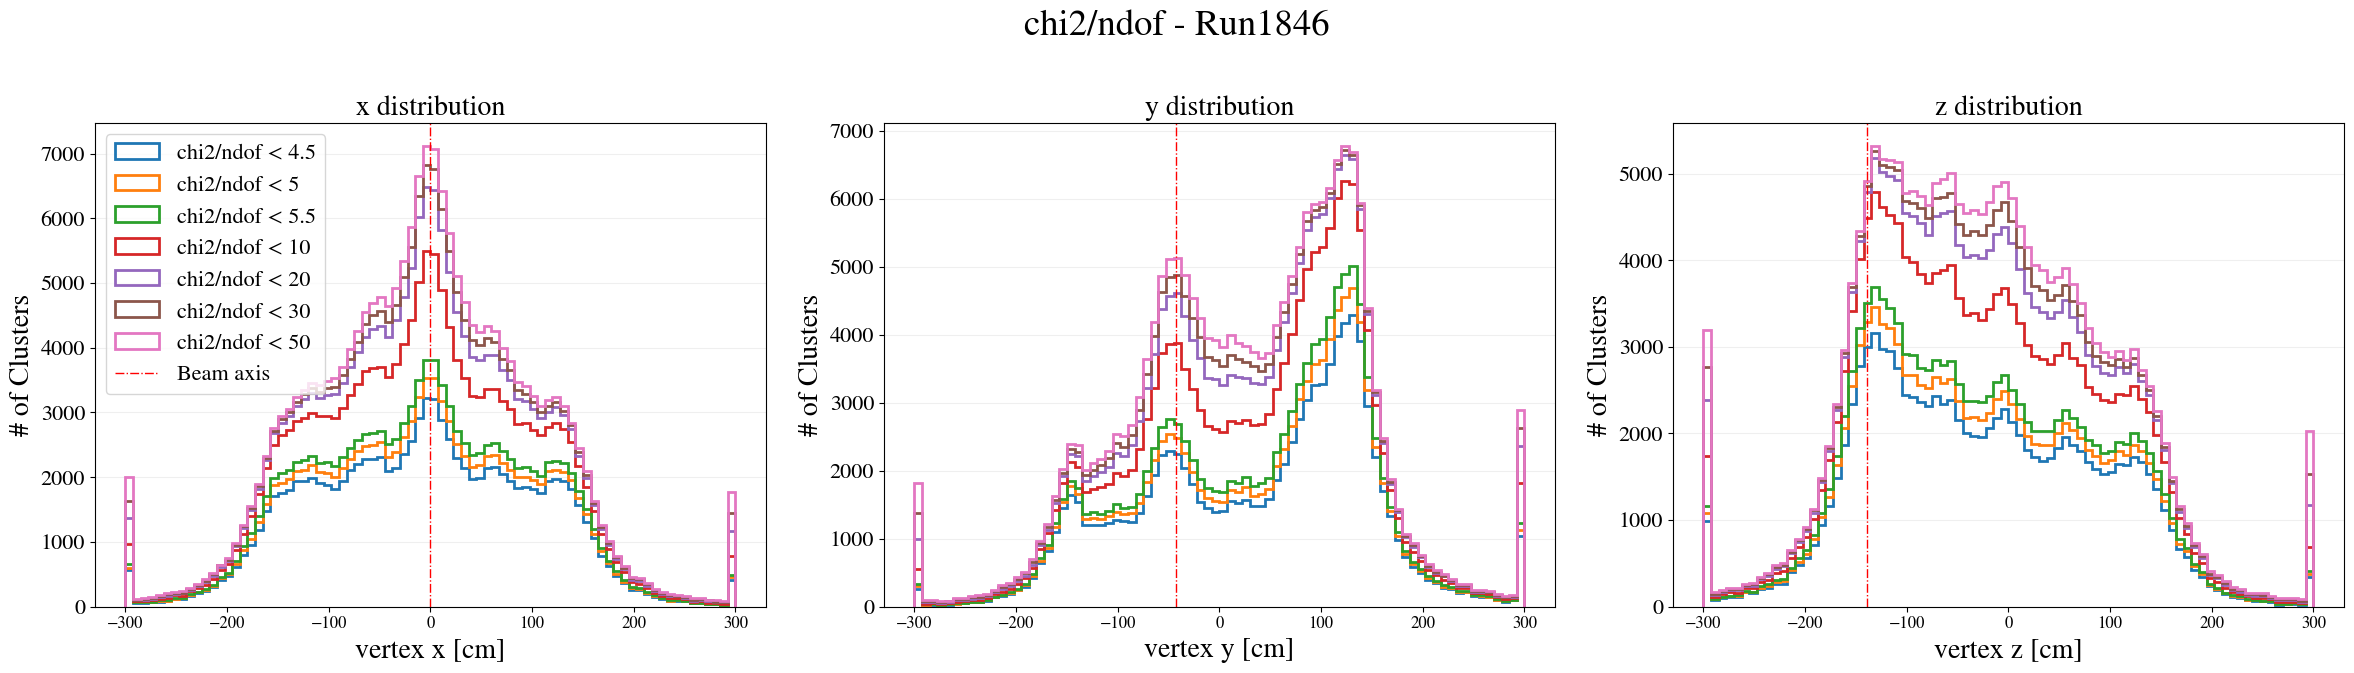

In [39]:

titles = ['x distribution', 'y distribution', 'z distribution']
quality_cuts = [4.5, 5, 5.5, 10, 20, 30, 50]

fig, axs = plt.subplots(1, 3, figsize=(24, 7))


#valid_data = df_all[df_all['fit_success'] == True]
plot_source = valid_data 

for i, ax in enumerate(axs):
    for cut in quality_cuts:
        df_temp = plot_source[plot_source['chi2_ndof'] < cut]
        
        # Plot step histogram for the current coordinate
        ax.hist(df_temp[coords[i]], bins=80, range=(-300, 300), 
                histtype='step', linewidth=2, label=f'chi2/ndof < {cut}')


    ax.axvline(beam_coords[i], color='red', linestyle='-.', linewidth=1, label=f'Beam axis')

    ax.set_title(titles[i])
    ax.set_xlabel(labels[i])
    ax.set_ylabel("# of Clusters")
    ax.grid(axis='y', alpha=0.2)
    
    # legend only on the first plot 
    if i == 0:
        ax.legend(loc='upper left')

plt.suptitle(f'chi2/ndof - Run{run_number}')
plt.tight_layout()
plt.show()

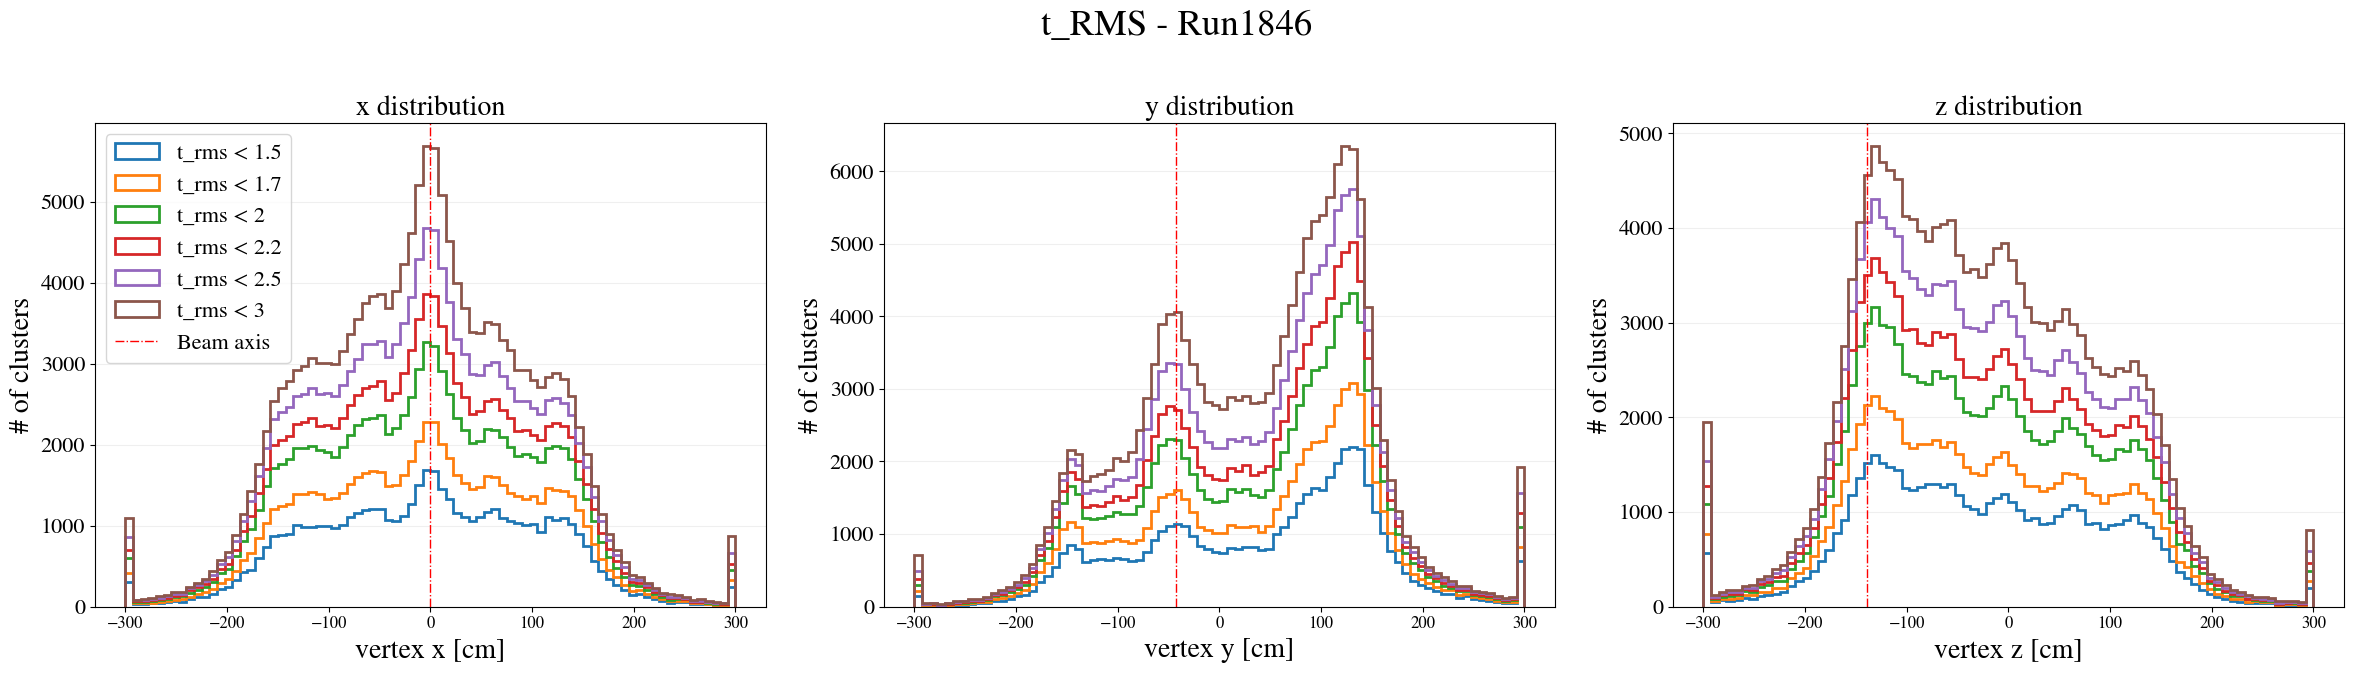

In [40]:

titles = ['x distribution', 'y distribution', 'z distribution']
quality_cuts = [1.5, 1.7, 2, 2.2, 2.5,3]

fig, axs = plt.subplots(1, 3, figsize=(24, 7))


#valid_data = df_all[df_all['fit_success'] == True]
plot_source = valid_data 

for i, ax in enumerate(axs):
    for cut in quality_cuts:
        df_temp = plot_source[plot_source['time_rms'] < cut]
        
        # Plot step histogram for the current coordinate
        ax.hist(df_temp[coords[i]], bins=80, range=(-300, 300), 
                histtype='step', linewidth=2, label=f't_rms < {cut}')


    ax.axvline(beam_coords[i], color='red', linestyle='-.', linewidth=1, label=f'Beam axis')

    ax.set_title(titles[i])
    ax.set_xlabel(labels[i])
    ax.set_ylabel("# of clusters")
    ax.grid(axis='y', alpha=0.2)
    
    # legend only on the first plot 
    if i == 0:
        ax.legend(loc='upper left')

plt.suptitle(f't_RMS - Run{run_number}')
plt.tight_layout()
plt.show()

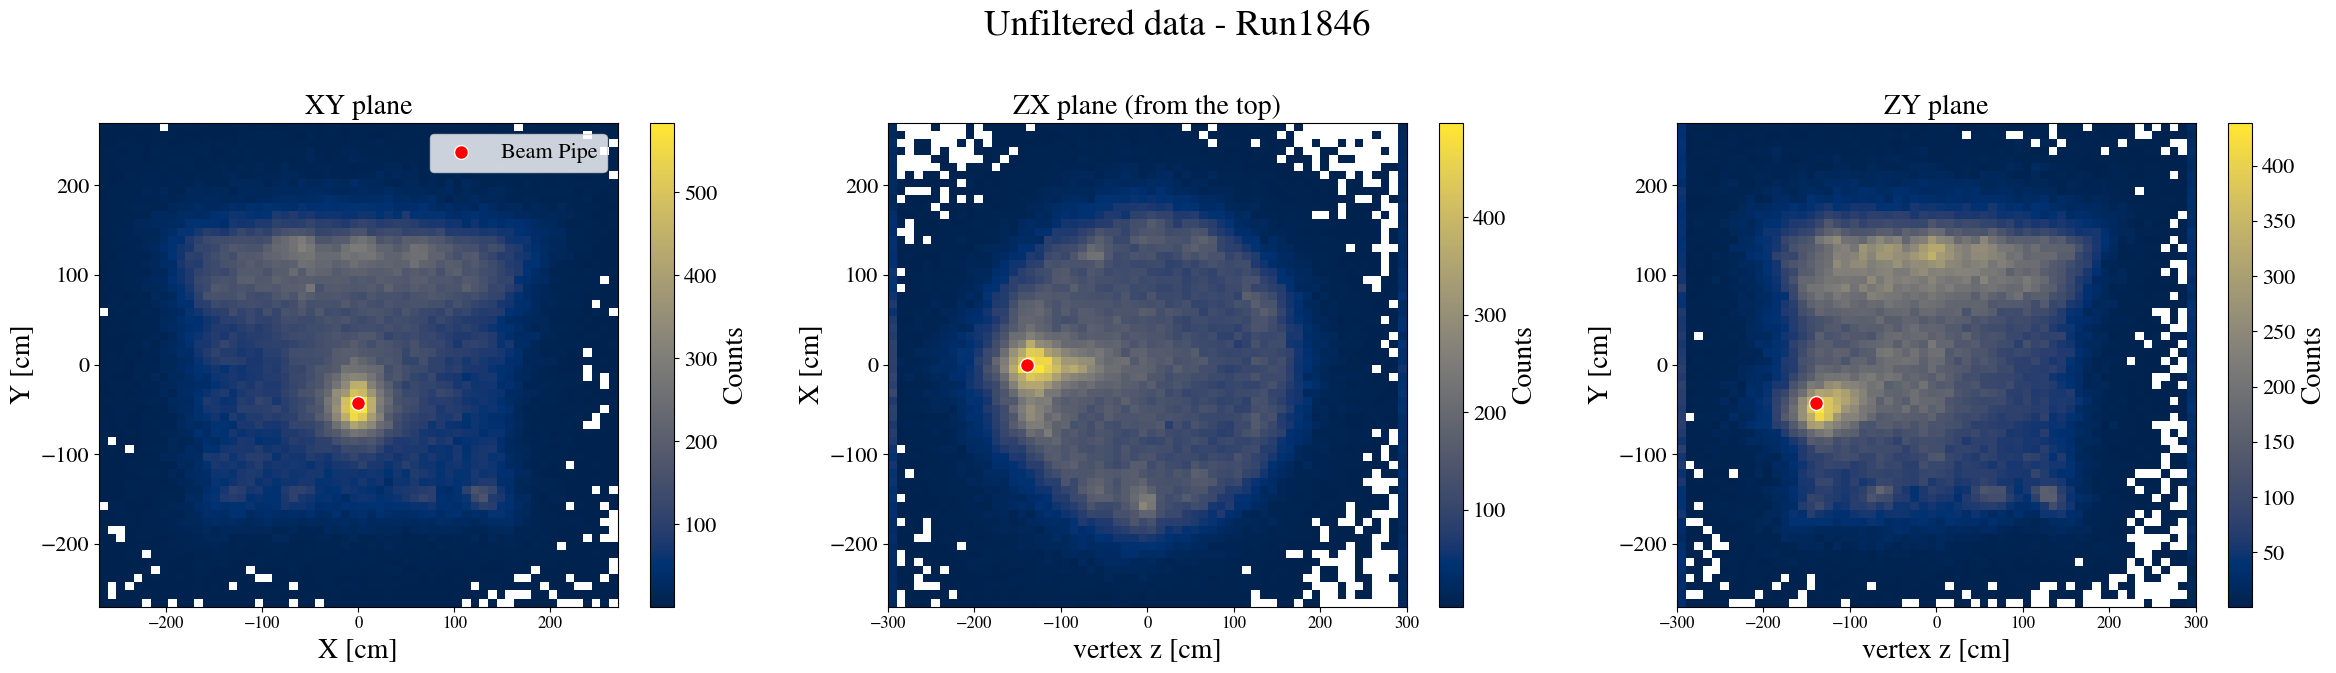

In [41]:
mask = (df_all['fit_success'] == True) & \
       (df_all['vertex_x'].abs() < 270) & \
       (df_all['vertex_y'].abs() < 270)

df_clean = df_all[mask].copy()

fig, axs = plt.subplots(1, 3, figsize=(24, 7))


beam_pipe = [0.0, -42.47, -138.79] 

# Plano XY 
im0 = axs[0].hist2d(df_clean['vertex_x'], df_clean['vertex_y'], bins=60, cmap='cividis', cmin=1)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe')
axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
axs[0].legend(loc='upper right')
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# Plano ZX 
im1 = axs[1].hist2d(df_clean['vertex_z'], df_clean['vertex_x'], bins=60, cmap='cividis', cmin=1)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white')
axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# Plano ZY 
im2 = axs[2].hist2d(df_clean['vertex_z'], df_clean['vertex_y'], bins=60, cmap='cividis', cmin=1)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white')
axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')

plt.suptitle(f"Unfiltered data - Run{run_number}")
plt.tight_layout()
plt.show()

mask = ((df_all['fit_success'] == True) & \
        (df_all['chi2_ndof'] < 5) & \
        (df_all['vertex_x'] >= beam_x - delta) & (df_all['vertex_x'] <= beam_x + delta) & \
        (df_all['vertex_y'] >= beam_y - delta) & (df_all['vertex_y'] <= beam_y + delta) & \
        (df_all['vertex_z'] >= beam_z - delta) & (df_all['vertex_z'] <= beam_z + delta))


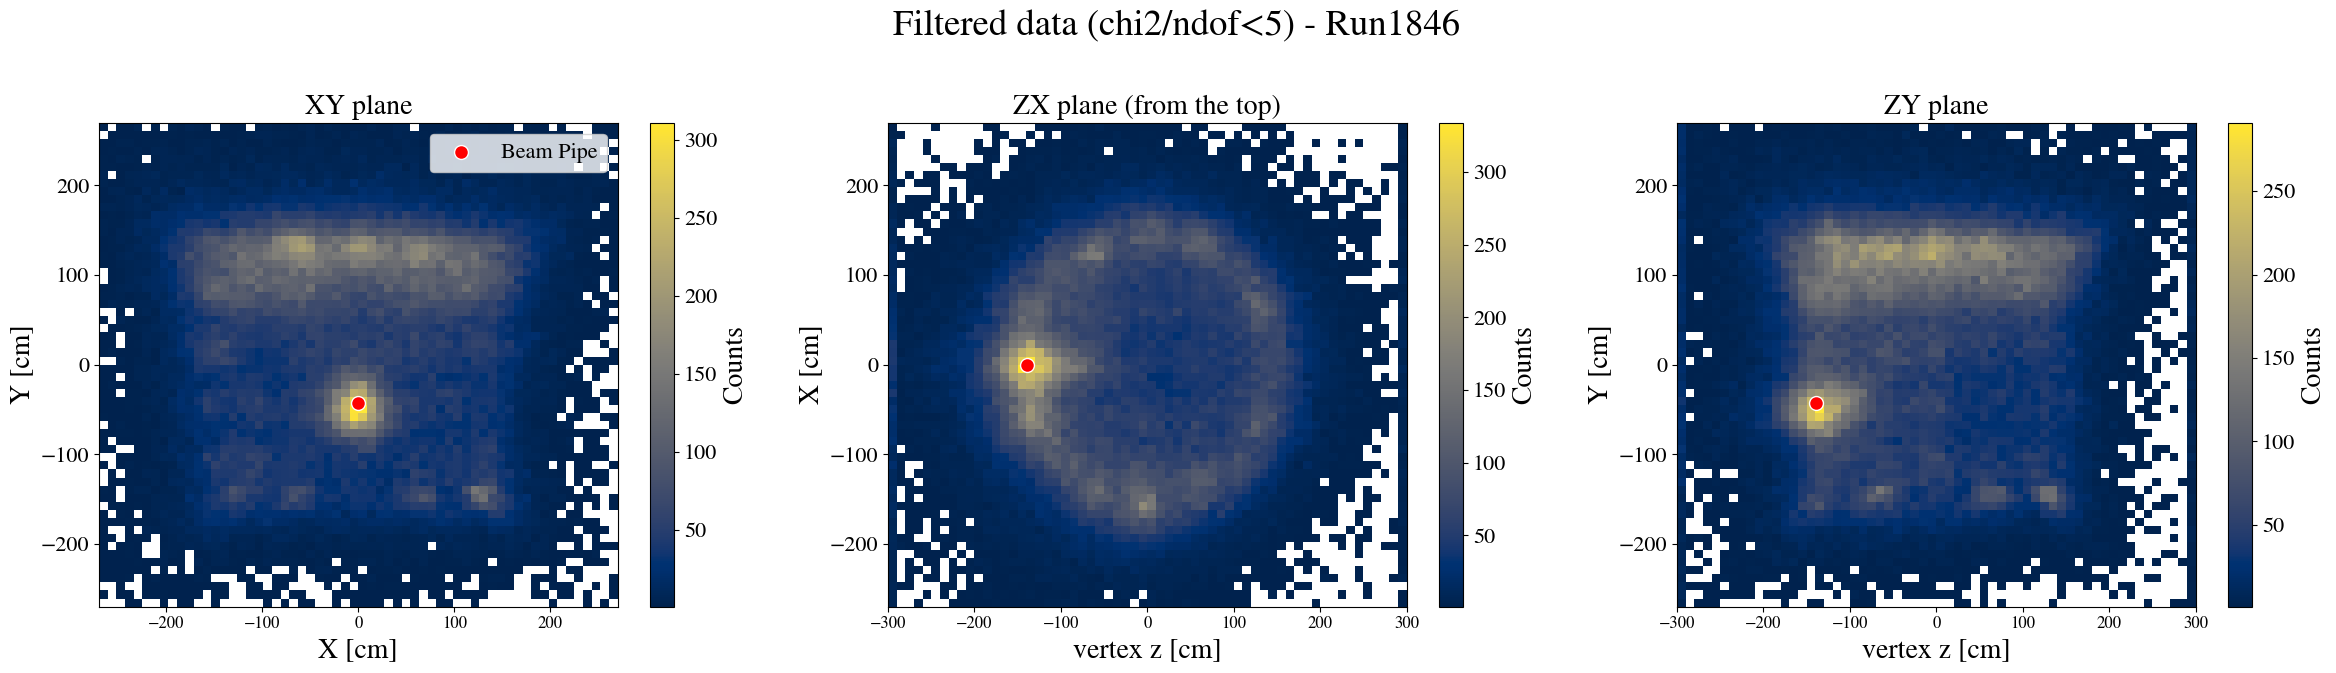

In [42]:
mask = (df_all['fit_success'] == True) & \
       (df_all['chi2_ndof'] < 5) & \
       (df_all['vertex_x'].abs() < 270) & \
       (df_all['vertex_y'].abs() < 270)


df_clean = df_all[mask].copy()

fig, axs = plt.subplots(1, 3, figsize=(24, 7))


beam_pipe = [0.0, -42.47, -138.79] 

# plano XY 
im0 = axs[0].hist2d(df_clean['vertex_x'], df_clean['vertex_y'], bins=60, cmap='cividis', cmin=1)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe')
axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
axs[0].legend(loc='upper right')
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# plano ZX 
im1 = axs[1].hist2d(df_clean['vertex_z'], df_clean['vertex_x'], bins=60, cmap='cividis', cmin=1)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white')
axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# plano ZY 
im2 = axs[2].hist2d(df_clean['vertex_z'], df_clean['vertex_y'], bins=60, cmap='cividis', cmin=1)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white')
axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')



plt.suptitle(f"Filtered data (chi2/ndof<5) - Run{run_number}")
plt.tight_layout()
plt.show()

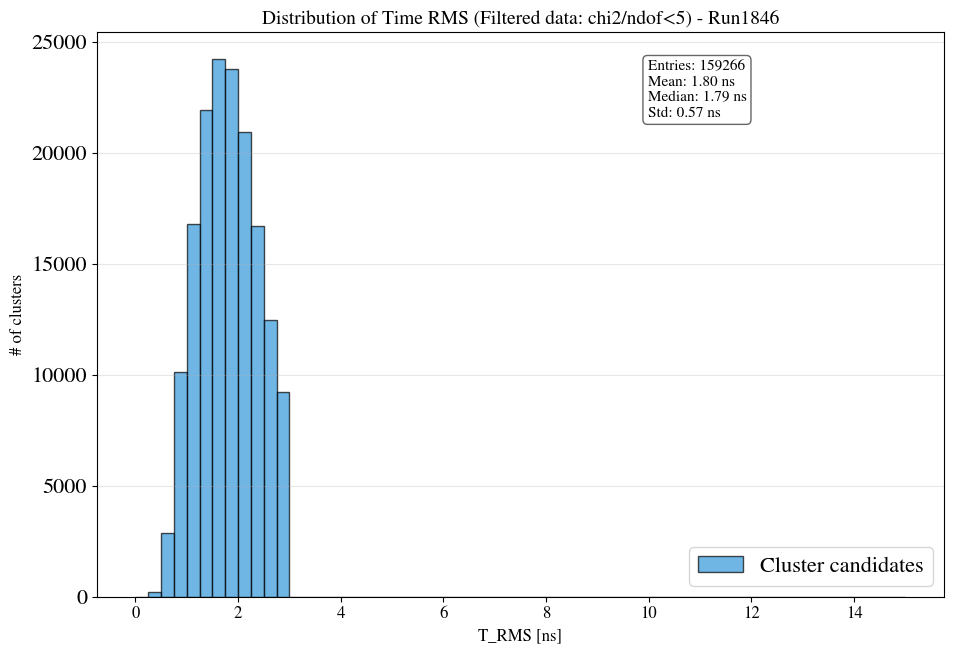

In [43]:
mask = (df_all['fit_success'] == True) & \
       (df_all['time_rms'] < 3) & \
       (df_all['vertex_x'].abs() < 270) & \
       (df_all['vertex_y'].abs() < 270)


df_clean = df_all[mask].copy()

plt.figure(figsize=(10, 7))

rms_data = df_clean['time_rms'].dropna()
n, bins, patches = plt.hist(rms_data, bins=60, range=(0, 15), color='#3498db', alpha=0.7, edgecolor='black', label='Cluster candidates')


plt.title(f"Distribution of Time RMS (Filtered data: chi2/ndof<5) - Run{run_number}", fontsize=14)
plt.xlabel("T_RMS [ns]", fontsize=12)
plt.ylabel("# of clusters", fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Mostrar estadísticas en el gráfico
textstr = '\n'.join((
    f'Entries: {len(rms_data)}',
    f'Mean: {rms_data.mean():.2f} ns',
    f'Median: {rms_data.median():.2f} ns',
    f'Std: {rms_data.std():.2f} ns'
))

props = dict(boxstyle='round', facecolor='white', alpha=0.6)
plt.text(0.65, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

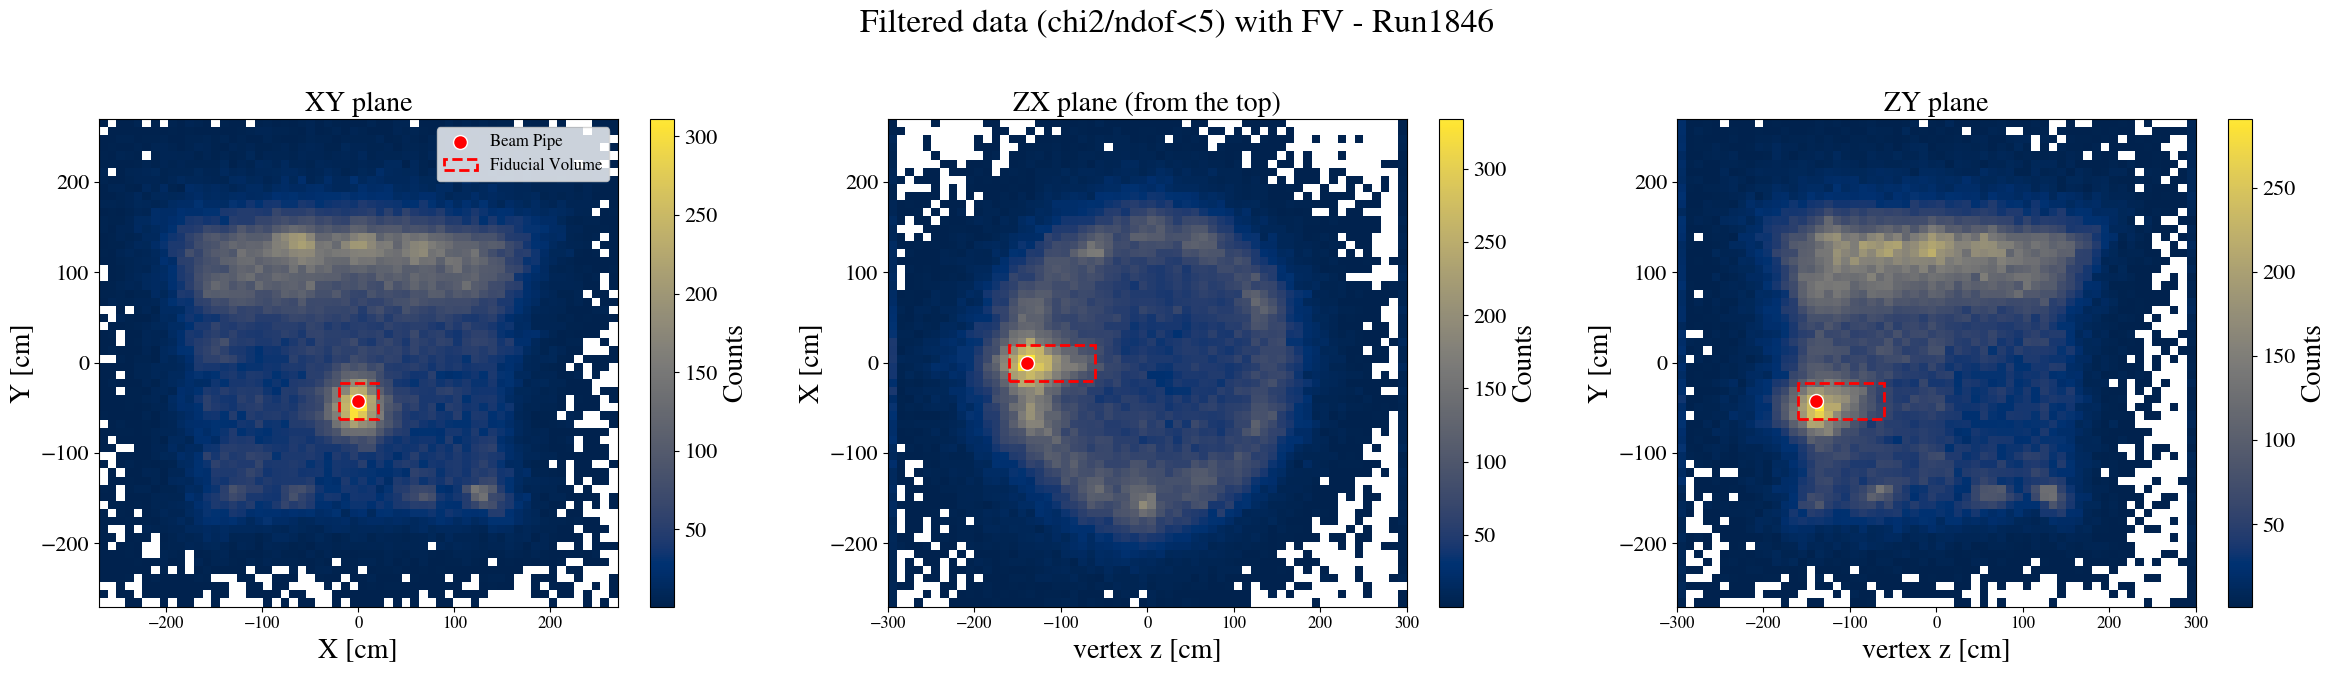

In [44]:
import matplotlib.patches as patches


mask = (df_all['fit_success'] == True) & \
       (df_all['chi2_ndof'] < 5) & \
       (df_all['vertex_x'].abs() < 270) & \
       (df_all['vertex_y'].abs() < 270)

df_clean = df_all[mask].copy()


fig, axs = plt.subplots(1, 3, figsize=(24, 7))
beam_pipe = [0.0, -42.47, -138.79] 

#Kouki's cuts
#x_lims = [-20, 20]
#y_lims = [-20, 20]
#z_lims = [-160, -60]

x_lims = [-20, 20]
y_lims = [-62, -22]
z_lims = [-160, -60]


box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')


#XY plane
im0 = axs[0].hist2d(df_clean['vertex_x'], df_clean['vertex_y'], bins=60, cmap='cividis', cmin=1)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)

#overlap FV
rect_xy = patches.Rectangle((x_lims[0], y_lims[0]), 
                           x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], 
                           **box_style, label='Fiducial Volume')
axs[0].add_patch(rect_xy)


axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
axs[0].legend(loc='upper right', fontsize=12)
plt.colorbar(im0[3], ax=axs[0], label='Counts')


#ZX plane
im1 = axs[1].hist2d(df_clean['vertex_z'], df_clean['vertex_x'], bins=60, cmap='cividis', cmin=1)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)


rect_zx = patches.Rectangle((z_lims[0], x_lims[0]), 
                           z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], 
                           **box_style)
axs[1].add_patch(rect_zx)


axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')


#ZY plane
im2 = axs[2].hist2d(df_clean['vertex_z'], df_clean['vertex_y'], bins=60, cmap='cividis', cmin=1)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)


rect_zy = patches.Rectangle((z_lims[0], y_lims[0]), 
                           z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], 
                           **box_style)
axs[2].add_patch(rect_zy)


axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')


plt.suptitle(f"Filtered data (chi2/ndof<5) with FV - Run{run_number}", fontsize=24)
plt.tight_layout()
plt.show()

In [45]:
total_events = len(df_all)
passed_events = len(df_clean)
percentage = (passed_events / total_events) * 100


print(f"Total clusters analyzed: {total_events}")
print(f"Events satisfying mask (chi2_ndof<5):  {passed_events}")
print(f"Selection efficiency:    {percentage:.2f}%")

Total clusters analyzed: 201875
Events satisfying mask (chi2_ndof<5):  107806
Selection efficiency:    53.40%


In [46]:
mask_fiducial = (
    (df_all['vertex_x'] > x_lims[0]) & (df_all['vertex_x'] < x_lims[1]) &
    (df_all['vertex_y'] > y_lims[0]) & (df_all['vertex_y'] < y_lims[1]) &
    (df_all['vertex_z'] > z_lims[0]) & (df_all['vertex_z'] < z_lims[1])
)

final_mask = (df_all['fit_success'] == True) & \
             (df_all['chi2_ndof'] < 5) & \
             mask_fiducial

df_final_candidates = df_all[final_mask].copy()

n_total = len(df_all)
n_fiducial = len(df_final_candidates)


print(f"Total events in df_all: {n_total}")
print(f"Events in FV: {n_fiducial}")
print(f"fraction: {(n_fiducial/n_total)*100:.3f}%")

Total events in df_all: 201875
Events in FV: 3087
fraction: 1.529%


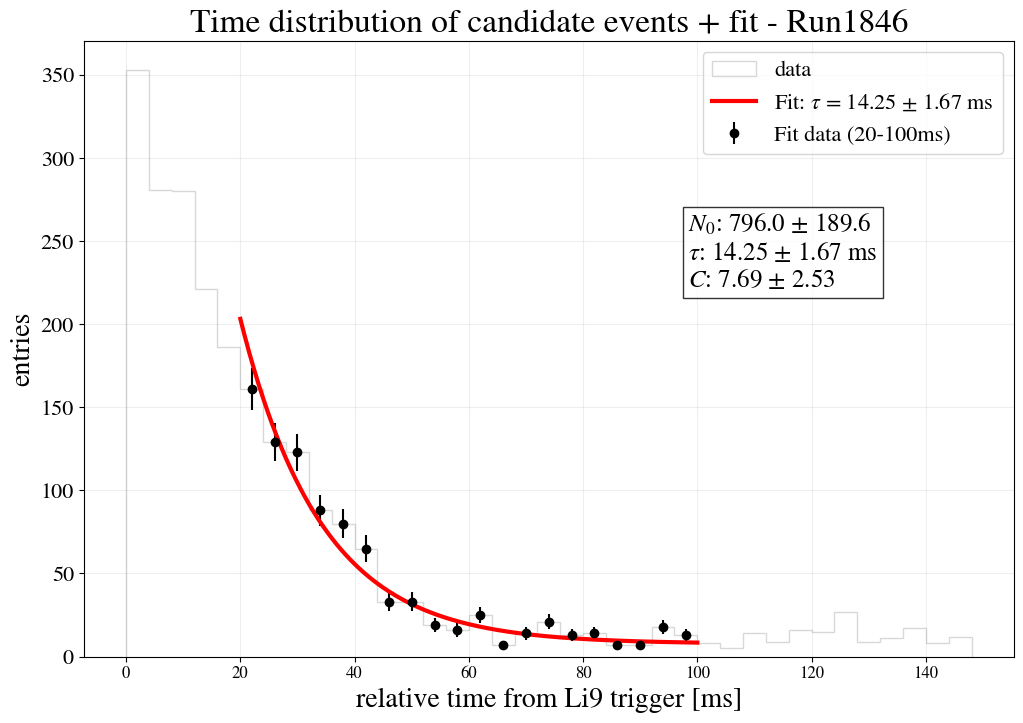

Total candidates in fiducial volume: 3087


In [47]:
from scipy.optimize import curve_fit


#time relative to the trigger in ms

df_final_candidates['t_ms'] = df_final_candidates['t_window_start_rel_ns'] / 1e6

#20ms to 100ms as Kouki
bin_width = 4
fit_bins = np.arange(20, 100 + bin_width, bin_width)
counts, bin_edges = np.histogram(df_final_candidates['t_ms'], bins=fit_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# N(t) = N0 * exp(-t/tau) + C
def decay_func(t, N0, tau, C):
    return N0 * np.exp(-t / tau) + C

#seed
p0 = [counts.max(), 13.6, 1.0] 

#fit with Poisson weighting (sigma = sqrt(N))
popt, pcov = curve_fit(decay_func, bin_centers, counts, p0=p0, sigma=np.sqrt(counts + 1))
errors = np.sqrt(np.diag(pcov))

#plot
plt.figure(figsize=(12, 8))


plt.hist(df_final_candidates['t_ms'], bins=np.arange(0, 150, bin_width), 
         histtype='step', color='gray', alpha=0.3, label='data')

#data points used for fit
plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='ko', label='Fit data (20-100ms)')

t_plot = np.linspace(20, 100, 200)
plt.plot(t_plot, decay_func(t_plot, *popt), 'r-', linewidth=3, 
         label=f'Fit: $\\tau$ = {popt[1]:.2f} ± {errors[1]:.2f} ms')


plt.title(f"Time distribution of candidate events + fit - Run{run_number}", fontsize=24)
plt.xlabel("relative time from Li9 trigger [ms]", fontsize=20)
plt.ylabel("entries", fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.2)

# Stats box
stats = (f"$N_0$: {popt[0]:.1f} ± {errors[0]:.1f}\n"
         f"$\\tau$: {popt[1]:.2f} ± {errors[1]:.2f} ms\n"
         f"$C$: {popt[2]:.2f} ± {errors[2]:.2f}")
plt.gca().text(0.65, 0.6, stats, transform=plt.gca().transAxes, 
               bbox=dict(facecolor='white', alpha=0.8), fontsize=18)

plt.show()

print(f"Total candidates in fiducial volume: {len(df_final_candidates)}")

In [48]:
#in ms
df_all['t_window_start_rel_ms'] = df_all['t_window_start_rel_ns'] / 1e6

mask = df_all['fit_success'] == True
df_filtered = df_all[mask]

print(f"Events ready for plotting: {len(df_filtered)}")

Events ready for plotting: 200366


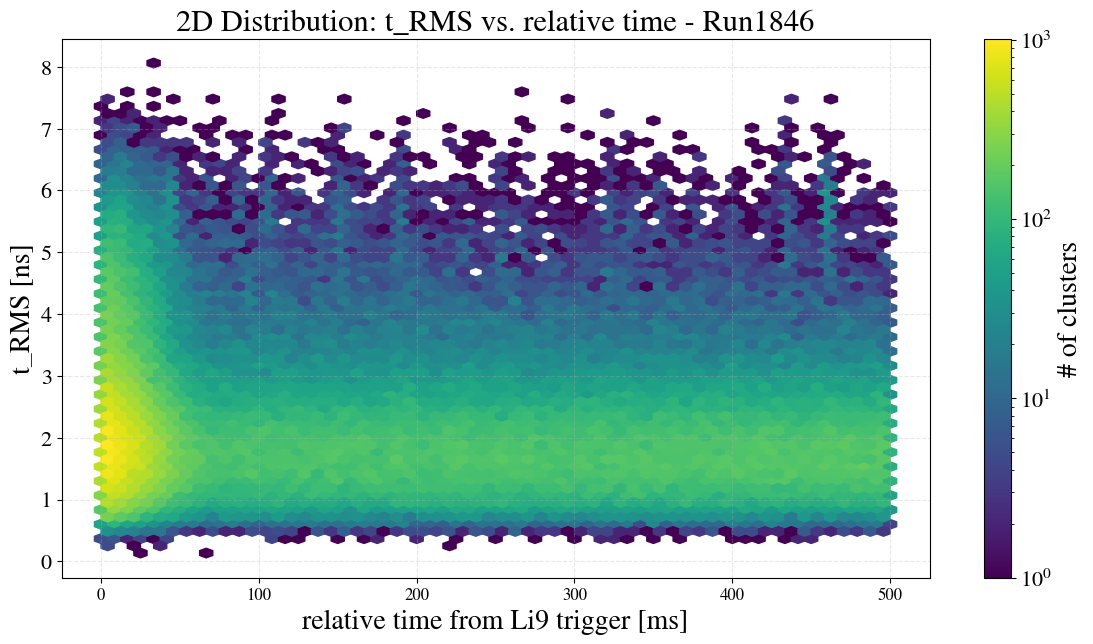

In [49]:
plt.figure(figsize=(14, 7))

# We use hexbin with log scaling to handle high density near t=0
hb = plt.hexbin(df_filtered['t_window_start_rel_ms'], 
                df_filtered['time_rms'], 
                gridsize=60, cmap='viridis', bins='log')

cb = plt.colorbar(hb)
cb.set_label('# of clusters')
plt.title(f'2D Distribution: t_RMS vs. relative time - Run{run_number}', fontsize=22)
plt.xlabel('relative time from Li9 trigger [ms]', fontsize=20)
plt.ylabel("t_RMS [ns]", fontsize=20)
plt.grid(alpha=0.3, linestyle='--')

plt.show()

# t_rms < 3ns + re-run Multilateration to the filtered events!

##### go to """multilat_vertex_2nd_iteration.ipynb"""